### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [88]:
#The path of the coupons.csv dataset may need to be changed depending on directory structure
data = pd.read_csv('/content/coupons.csv')

In [89]:
# Rename the "Y" column to "Accepted"
data = data.rename(columns = {"Y" : "Accepted"})

#Replaced values for income to strip the dollar sign and make them shorter for easier display
data["income"] = data["income"].str.replace("Less than $12500", "0-12,499")
data["income"] = data["income"].str.replace("$12500 - $24999", "12,500-24,999")
data["income"] = data["income"].str.replace("$25000 - $37499", "25,000-37,499")
data["income"] = data["income"].str.replace("$37500 - $49999", "37,500-49,999")
data["income"] = data["income"].str.replace("$50000 - $62499", "50,000-62,499")
data["income"] = data["income"].str.replace("$62500 - $74999", "62,500-74,999")
data["income"] = data["income"].str.replace("$75000 - $87499", "75,000-87,499")
data["income"] = data["income"].str.replace("$87500 - $99999", "87,500-99,999")
data["income"] = data["income"].str.replace("$100000 or More", "More than 100,000")

#data.head()
print(data["income"].head(5))

0    37,500-49,999
1    37,500-49,999
2    37,500-49,999
3    37,500-49,999
4    37,500-49,999
Name: income, dtype: object


2. Investigate the dataset for missing or problematic data.

In [90]:
#My goal here was to see the quantity of each coupon type accepted.
#I used a Plotly bar plot to show the number of each coupon type accepted.
#The bar shows the Coupon Type and Number Accepted when you hover over the bar.
sum_by_coupon = data.groupby("coupon")[["Accepted"]].agg(sum)

sum_by_coupon["Coupon"] = sum_by_coupon.index

print(sum_by_coupon)

px.bar(sum_by_coupon, x = "Coupon", y = "Accepted", color = "Coupon")

                       Accepted                 Coupon
coupon                                                
Bar                         827                    Bar
Carry out & Take away      1760  Carry out & Take away
Coffee House               1995           Coffee House
Restaurant(20-50)           658      Restaurant(20-50)
Restaurant(<20)            1970        Restaurant(<20)


/tmp/ipykernel_156/3690283564.py:4: FutureWarning:

The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.



Based solely on number coupons accepted, the bar chart above indicates that Carry Out & Take Away, Coffee Houses and inexpensive Restaurants had the biggest numbers for coupon acceptance. Common themes among those three categories are they are inexpensive and relatively fast purchases.

3. Decide what to do about your missing data -- drop, replace, other...

**Here is a summary of data and columns that I changed and/or replaced:**

Throughout the notebook I created subset dataframes as required to solve the question(s) posed.

In the first codebox on the top of notebook:
Imported plotly: import plotly.graph_objects as go.

Number 1:
Renamed the "Y" column to "Accepted" .
Replaced the values of the "income" column to make them shorter and easier to work with.

Number 4:
Replaced for "age" column value "below 21".

Number 5:
Renamed the "passanger" column to "passenger".

4. What proportion of the total observations chose to accept the coupon?

**Note: I produced additional plots after the histogram in number 5 below to help answer the question above.**



In [91]:
#get total counts
coupon_counts = data["coupon"].value_counts()

print(coupon_counts)

#convert to a dataframe
df_coupon_counts = pd.DataFrame(coupon_counts)

print(df_coupon_counts)


coupon
Coffee House             3996
Restaurant(<20)          2786
Carry out & Take away    2393
Bar                      2017
Restaurant(20-50)        1492
Name: count, dtype: int64
                       count
coupon                      
Coffee House            3996
Restaurant(<20)         2786
Carry out & Take away   2393
Bar                     2017
Restaurant(20-50)       1492


5. Use a bar plot to visualize the `coupon` column.

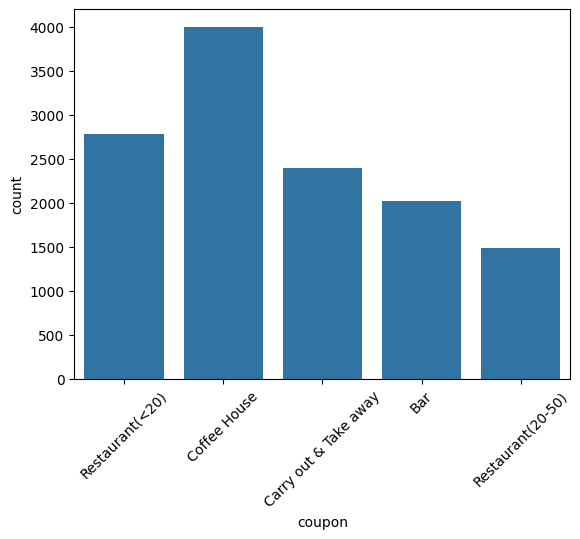

In [92]:
#I initially used Seaborn to create the bar plot below.
#Later after exercise number 6 below, I used Plotly to visualize coupon data.

sns.countplot(x = "coupon", data = data)
#sns.countplot(x = "coupon", data = sum_by_coupon)
plt.xticks(rotation = 45)
plt.show()


6. Use a histogram to visualize the temperature column.

**Note:** I created 2 additional (Plotly) plots to visualize Coupon data below (after the histogram). I like the hover feature of Plotly because it helps highlight important information.

In [93]:
#temp_and_accepted = data[["tempurature", "Accepted"]]
#temp_and_accepted = data.query('Accepted == 1')[["tempurature"]]

temp_and_accepted = data.query("Accepted == 1")[["temperature"]]
#print(temp_and_accepted)

print(temp_and_accepted.head(5))

px.histogram(temp_and_accepted, labels = {"value" : "Temperature"}, title = "Accepted Coupons by Temperature")




   temperature
0           55
2           80
5           80
6           55
7           80


Based on the histogram above it appears that people are more amenable to going out to do things in warmer weather.

**In the cells below I enhanced the visualization of the coupon data:**

In [94]:
#I merged coupon totals with coupons accepted

merged_coupon_data = pd.merge(sum_by_coupon, df_coupon_counts, on = "coupon")
print(merged_coupon_data)

                       Accepted                 Coupon  count
coupon                                                       
Bar                         827                    Bar   2017
Carry out & Take away      1760  Carry out & Take away   2393
Coffee House               1995           Coffee House   3996
Restaurant(20-50)           658      Restaurant(20-50)   1492
Restaurant(<20)            1970        Restaurant(<20)   2786


In [95]:
#Show a multi-bar plot to show numbers of coupoms offered and accepted using Plotly

coupon_multi_bar = go.Figure(data = [
    go.Bar(name =
           "Coupons Offered", x = merged_coupon_data["Coupon"], y = merged_coupon_data["count"]),
    go.Bar(name =
           "Coupons Accepted", x = merged_coupon_data["Coupon"], y = merged_coupon_data["Accepted"])
])

coupon_multi_bar.update_layout(
    barmode = "group",
    title = "Number of Coupons Offered and Accepted",
    xaxis_title = "Coupons",
    yaxis_title = "Counts"

)

coupon_multi_bar.show()



**Below I enhanced the multi-bar plot by computing and showing % accepted for each coupon bar:**

In [96]:
merged_coupon_data["Percent"] = ((merged_coupon_data["Accepted"] / merged_coupon_data["count"]) * 100).round(1)

print(merged_coupon_data)



                       Accepted                 Coupon  count  Percent
coupon                                                                
Bar                         827                    Bar   2017     41.0
Carry out & Take away      1760  Carry out & Take away   2393     73.5
Coffee House               1995           Coffee House   3996     49.9
Restaurant(20-50)           658      Restaurant(20-50)   1492     44.1
Restaurant(<20)            1970        Restaurant(<20)   2786     70.7


In [97]:
coupon_multi_bar = go.Figure(data = [
    go.Bar(name =
           "Coupons Offered", x = merged_coupon_data["Coupon"], y = merged_coupon_data["count"]),
    go.Bar(name =
           "Coupons Accepted", x = merged_coupon_data["Coupon"], y = merged_coupon_data["Accepted"],
            text = merged_coupon_data["Percent"].astype(str) + "%", textposition = "outside")
])

coupon_multi_bar.update_layout(
    barmode = "group",
    title = "Number of Coupons Offered and Accepted",
    xaxis_title = "Coupons",
    yaxis_title = "Counts"

)

coupon_multi_bar.show()

Interesting observation from the multi-bar plot above is that the percentage acceptance rates of Carry Out & Take Away and Inexpensive Restaurants were > 70%. Even though Coffee Houses had the highest number of acceptances, the percent of acceptance was slightly leass than 50%.

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [98]:
#Create dataframe for bar coupons only

bar_coupons_only = data.query('coupon == "Bar"')[["coupon", "Bar"]]

print(bar_coupons_only.head(5))
print()

bar_coupons_only_rows = bar_coupons_only.shape[0]
print("Number of Bar Coupons = ", bar_coupons_only_rows)


   coupon    Bar
9     Bar  never
13    Bar  never
17    Bar  never
24    Bar  never
35    Bar  never

Number of Bar Coupons =  2017


2. What proportion of bar coupons were accepted?


In [99]:
#See multi-barplots above. They show counts and percents for all coupons including Bar coupons.

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [100]:
#3 or fewer = "never" + "less1" + "1~3"
#more than 3 = "4~8" + "gt8"

bar_coupons_compare = bar_coupons_only["Bar"].value_counts().reset_index()

print(bar_coupons_compare)

#three_or_fewer = ("never", "less1", "1~3")
three_or_fewer = (0, 1, 2)
#more_than_three = ("4~8", "gt8")
more_than_three = (3, 4)

three_or_fewer_count = bar_coupons_compare[bar_coupons_compare.index.isin(three_or_fewer)].sum()
more_than_three_count = bar_coupons_compare[bar_coupons_compare.index.isin(more_than_three)].sum()

print()
print("3 or Fewer = ", three_or_fewer_count["count"])
print("More than 3 = ", more_than_three_count["count"])

diff_factor = round((three_or_fewer_count["count"] / more_than_three_count["count"]), 2)
print("There is a", diff_factor, "X difference")

     Bar  count
0  never    830
1  less1    570
2    1~3    397
3    4~8    150
4    gt8     49

3 or Fewer =  1797
More than 3 =  199
There is a 9.03 X difference


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [101]:
#go to bar > 1/month AND
#> age 25

bar_coupons_and_age = data.query("coupon == 'Bar'")[["coupon", "Bar", "age"]].reset_index()

print(bar_coupons_and_age.head(5))
print()
bar_coupons_and_age_rows = bar_coupons_and_age.shape[0]
print("Number of Bar Coupons Accepted = ", bar_coupons_and_age_rows)
print()

more_than_once_per_month = ("1~3", "4~8", "gt8")
less_than_once_per_month  = ("never", "less1")

bar_coupons_and_age["age"] = bar_coupons_and_age["age"].str.replace("below21", "20")

accept_bar_and_age = bar_coupons_and_age.query('age > "25"')[["Bar", "age"]].reset_index()

#print(accept_bar_and_age.head(5))
accept_bar_and_age_rows = accept_bar_and_age.shape[0]
print("Number of Bar Coupons Accepted by People Over 25 = ",accept_bar_and_age_rows)
print()

accept_bar_and_age_more_one = accept_bar_and_age.query('Bar in @more_than_once_per_month').reset_index()

#print(accept_bar_and_age_more_one.head(5))
accept_bar_and_age_more_one_rows = accept_bar_and_age_more_one.shape[0]
print("Number of Bar Coupons Accepted by People Over 25 that Go To a Bar More Than Once/month = ", accept_bar_and_age_more_one_rows)


   index coupon    Bar age
0      9    Bar  never  21
1     13    Bar  never  21
2     17    Bar  never  21
3     24    Bar  never  21
4     35    Bar  never  21

Number of Bar Coupons Accepted =  2017

Number of Bar Coupons Accepted by People Over 25 =  1513

Number of Bar Coupons Accepted by People Over 25 that Go To a Bar More Than Once/month =  420


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [102]:
#go to Bars > 1/month AND
#passengers that were NOT kid(s) AND
#occupations that are NOT farming, fishing or forestry

bar_coupons_subset = data.query("coupon == 'Bar'")[["coupon", "Bar", "passanger", "occupation"]].reset_index()
bar_coupons_subset = bar_coupons_subset.rename(columns = {"passanger" : "passenger"})

print(bar_coupons_subset.head(5))
print()
bar_coupons_subset_rows = bar_coupons_subset.shape[0]
print("Number of Bar Coupons Accepted = ", bar_coupons_subset_rows)
print()

bar_coupons_subset_1month = bar_coupons_subset.query('Bar in @more_than_once_per_month').reset_index()

print(bar_coupons_subset_1month.head(5))
print()
bar_coupons_subset_1month_rows = bar_coupons_subset_1month.shape[0]
print("Number of Bar Coupons Accepted by People that Go To a Bar More Than Once/month = ", bar_coupons_subset_1month_rows)
print()


bar_coupons_subset_1month_nokid = bar_coupons_subset_1month.query('passenger != "Kid(s)"')

print(bar_coupons_subset_1month_nokid.head(5))
print()
bar_coupons_subset_1month_nokid_rows = bar_coupons_subset_1month_nokid.shape[0]
print("Number of Bar Coupons Accepted by People that Go To a Bar More Than Once/month and no kid passengers = ", bar_coupons_subset_1month_nokid_rows)
print()

bar_coupons_subset_1month_nokid_nofff = bar_coupons_subset_1month_nokid.query('occupation != "Farming Fishing & Forestry"')

print(bar_coupons_subset_1month_nokid_nofff.head(5))
print()
bar_coupons_subset_1month_nokid_nofff_rows = bar_coupons_subset_1month_nokid_nofff.shape[0]
print("Number of Bar Coupons Accepted by People that Go To a Bar More Than Once/month and no kid passengers and not Farm, Fish & Forest = ", bar_coupons_subset_1month_nokid_nofff_rows)


   index coupon    Bar  passenger                  occupation
0      9    Bar  never     Kid(s)                  Unemployed
1     13    Bar  never      Alone                  Unemployed
2     17    Bar  never      Alone                  Unemployed
3     24    Bar  never  Friend(s)  Architecture & Engineering
4     35    Bar  never      Alone  Architecture & Engineering

Number of Bar Coupons Accepted =  2017

   level_0  index coupon  Bar  passenger occupation
0       12     90    Bar  1~3  Friend(s)    Student
1       13    101    Bar  1~3      Alone    Student
2       14    105    Bar  1~3      Alone    Student
3       15    112    Bar  1~3  Friend(s)    Student
4       16    123    Bar  1~3      Alone    Student

Number of Bar Coupons Accepted by People that Go To a Bar More Than Once/month =  596

   level_0  index coupon  Bar  passenger occupation
0       12     90    Bar  1~3  Friend(s)    Student
1       13    101    Bar  1~3      Alone    Student
2       14    105    Bar  1~3  

The number of acceptances fell for People that Go To a Bar More Than Once/month and no kid passengers compared to People that Go To a Bar More Than Once/month (see above). I found no difference when excluding Farm, Fish & Forest.

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [103]:
#go to Bars > 1/month AND passengers NOT kid(s) AND not widowed OR
#go to Bars > 1/month AND < age 30 OR
#go to cheap restaurants > 4 times/month and income < 50k

bar_coupons_subset1 = data.query("coupon == 'Bar'")[["coupon", "Bar", "passanger", "maritalStatus", "age", "RestaurantLessThan20", "income"]].reset_index()
bar_coupons_subset1 = bar_coupons_subset1.rename(columns = {"passanger" : "passenger"})
bar_coupons_subset1["age"] = bar_coupons_subset1["age"].str.replace("below21", "20")

print(bar_coupons_subset1.head(5))
print()
bar_coupons_subset1_rows = bar_coupons_subset1.shape[0]
print("Number of Bar Coupons Accepted = ", bar_coupons_subset1_rows)
print()

bar_coupons_subset1_1mth_noK_noW = bar_coupons_subset1.query('Bar in @more_than_once_per_month and passenger != "Kid(s)" and maritalStatus != "Widowed"').reset_index()

print(bar_coupons_subset1_1mth_noK_noW.head(5))
print()
bar_coupons_subset1_1mth_noK_noW_rows = bar_coupons_subset1_1mth_noK_noW.shape[0]
print("Number of Bar Coupons Accepted: > 1/month and no kids and not widowed = ", bar_coupons_subset1_1mth_noK_noW_rows)
pct_bar_coupons_subset1_1mth_noK_noW = round(((bar_coupons_subset1_1mth_noK_noW_rows / bar_coupons_subset1_rows) * 100), 2)
print("Percent of Total Bar Coupons Accepted =                                 ", pct_bar_coupons_subset1_1mth_noK_noW, "%")
print()

bar_coupons_subset1_1mth_age30 = bar_coupons_subset1.query('Bar in @more_than_once_per_month and age > "30"').reset_index()

print(bar_coupons_subset1_1mth_age30.head(5))
print()
bar_coupons_subset1_1mth_age30_rows = bar_coupons_subset1_1mth_age30.shape[0]
print("Number of Bar Coupons Accepted: > 1/month and > age 30 = ", bar_coupons_subset1_1mth_age30_rows)
pct_bar_coupons_subset1_1mth_age30 = round(((bar_coupons_subset1_1mth_age30_rows / bar_coupons_subset1_rows) * 100), 2)
print("Percent of Total Bar Coupons Accepted =                  ", pct_bar_coupons_subset1_1mth_age30, "%")
print()

rest_gt4 = ("4~8", "gt8")
inc_lt50 = ("0-12,499", "12,500-24,999", "25,000-37,499", "37,500-49,999")
bar_coupons_subset1_chrest_inclt50 = bar_coupons_subset1.query('RestaurantLessThan20 in @rest_gt4 and income in @inc_lt50').reset_index()

print(bar_coupons_subset1_chrest_inclt50.head(5))
print()
bar_coupons_subset1_chrest_inclt50_rows = bar_coupons_subset1_chrest_inclt50.shape[0]
print("Number of Bar Coupons Accepted: > 4/month cheap restaurants and < income 50k = ", bar_coupons_subset1_chrest_inclt50_rows)
pct_bar_coupons_subset1_chrest_inclt50 = round(((bar_coupons_subset1_chrest_inclt50_rows / bar_coupons_subset1_rows) * 100), 2)
print("Percent of Total Bar Coupons Accepted =                                        ", pct_bar_coupons_subset1_chrest_inclt50, "%")
print()


   index coupon    Bar  passenger      maritalStatus age RestaurantLessThan20  \
0      9    Bar  never     Kid(s)  Unmarried partner  21                  4~8   
1     13    Bar  never      Alone  Unmarried partner  21                  4~8   
2     17    Bar  never      Alone  Unmarried partner  21                  4~8   
3     24    Bar  never  Friend(s)             Single  21                  4~8   
4     35    Bar  never      Alone             Single  21                  4~8   

          income  
0  37,500-49,999  
1  37,500-49,999  
2  37,500-49,999  
3  62,500-74,999  
4  62,500-74,999  

Number of Bar Coupons Accepted =  2017

   level_0  index coupon  Bar  passenger      maritalStatus age  \
0       12     90    Bar  1~3  Friend(s)             Single  21   
1       13    101    Bar  1~3      Alone             Single  21   
2       14    105    Bar  1~3      Alone             Single  21   
3       15    112    Bar  1~3  Friend(s)  Unmarried partner  26   
4       16    123    Ba

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

Of the scenarios presented directly above, the highest percentage of acceptance was from the popoulation defined as "**people that go to bars more than once a month, had passengers that were not a kid, and were not widowed**" at **27.32%**.

The population that was least likely to accept was the group described as "**people that go to bars more than once a month and are under the age of 30**" at **12.44%**.

It seems likely that not having kids in the car would increase the probability of acceptance. Considerations for a younger population (under age 30) may also include less disposable income to go to bars and greater awareness of health and focus on healthier activities.

Other factors to be considered:

1.   Offering bar coupons to drivers may present a safety issue that people want to avoid, i.e., drinking alcohol and driving.
2.   Bars tend to cater to specific populations like, sports bars, live-music clubs/bars, dance clubs/bars etc.
3. Overall trends of people consuming less alcohol and what age brackets are most affected.










### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [104]:
#I was curious to see the amount of Accepted Coupons for each value of Income Range
#Displayed below is a Plotly bar plot that will show the Number of Coupons Accepted and the Income range when you hover over the bar.

sum_by_income = data.groupby("income")[["Accepted"]].agg(sum).sort_values(by = "income")

sum_by_income["income"] = sum_by_income.index

print(sum_by_income)

px.bar(sum_by_income, x = "income", y = "Accepted", labels = {"income" : "Income in $"})

                   Accepted             income
income                                        
0-12,499                618           0-12,499
12,500-24,999          1052      12,500-24,999
25,000-37,499          1194      25,000-37,499
37,500-49,999          1018      37,500-49,999
50,000-62,499           988      50,000-62,499
62,500-74,999           446      62,500-74,999
75,000-87,499           414      75,000-87,499
87,500-99,999           476      87,500-99,999
More than 100,000      1004  More than 100,000


/tmp/ipykernel_156/4107969818.py:4: FutureWarning:

The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.



The Plotly Bar Plot above displays the Number of Coupons Accepted by each Income range bracket.

It is interesting that the number of accepted coupons is low for the lowest income bracket and then rises significantly for the next 4 brackets and then falls off for the next 3 brackets. This distribution of the first eight brackets looks something like a "normal" distribution with a long right tail.

However, the highest income bracket (the ninth bracket) shows a significant increase over the prior three income brackets. Suggesting perhaps that certain types of coupons are more appealing to higher incomes, like higher priced restaurants.